# Day 0 · A Taste of the Course
*Measuring Manuscripts*

A fast tour of the sort of thing this course does. We are going to skip most of the *how* and just show the *what*: a dozen quick demonstrations on real manuscripts, from counting words to reading handwriting by machine. Nothing here needs a programming background.

**How to run.** Click a grey code cell and press **Shift+Enter**. Go top to bottom. Two cells fetch data and take up to a minute. The rest are instant.

In [22]:
print("Hello, philology!")

Hello, philology!


# Part 1 · Text as data

Take a famous text and turn it into something countable. The text is the opening of Chaucer's *Canterbury Tales*, written in the 1390s in Middle English.

In [23]:
text = "Whan that Aprille with his shoures soote,\nThe droghte of March hath perced to the roote,\nAnd bathed every veyne in swich licour\nOf which vertu engendred is the flour;\nWhan Zephirus eek with his swete breeth\nInspired hath in every holt and heeth\nThe tendre croppes, and the yonge sonne\nHath in the Ram his halfe cours y-ronne,\nAnd smale foweles maken melodye,\nThat slepen al the nyght with open ye,\nSo priketh hem Nature in hir corages,\nThanne longen folk to goon on pilgrimages,\nAnd palmeres for to seken straunge strondes,\nTo ferne halwes, kowthe in sondry londes;\nAnd specially, from every shires ende\nOf Engelond, to Caunterbury they wende,\nThe hooly blisful martir for to seke,\nThat hem hath holpen whan that they were seeke."
print(text)

Whan that Aprille with his shoures soote,
The droghte of March hath perced to the roote,
And bathed every veyne in swich licour
Of which vertu engendred is the flour;
Whan Zephirus eek with his swete breeth
Inspired hath in every holt and heeth
The tendre croppes, and the yonge sonne
Hath in the Ram his halfe cours y-ronne,
And smale foweles maken melodye,
That slepen al the nyght with open ye,
So priketh hem Nature in hir corages,
Thanne longen folk to goon on pilgrimages,
And palmeres for to seken straunge strondes,
To ferne halwes, kowthe in sondry londes;
And specially, from every shires ende
Of Engelond, to Caunterbury they wende,
The hooly blisful martir for to seke,
That hem hath holpen whan that they were seeke.


A computer sees a string of characters. Split it on spaces and it becomes a list of *words* we can count. *Tokens* are running words, *types* are distinct words.

In [24]:
words = text.replace('\n', ' ').split()
types = set(w.lower().strip('.,;:') for w in words)
print('Tokens (running words):', len(words))
print('Types (distinct words):', len(types))
print('Type/token ratio:', round(len(types) / len(words), 2))

Tokens (running words): 128
Types (distinct words): 88
Type/token ratio: 0.69


### Zipf's law

Load the whole text from the course repository, count every word, and rank them. On log-log axes the counts fall on a near-straight line: a few words do most of the work, a long tail appears once each. Nobody put that there. Counting found it.

6,672 words, 1,790 distinct.


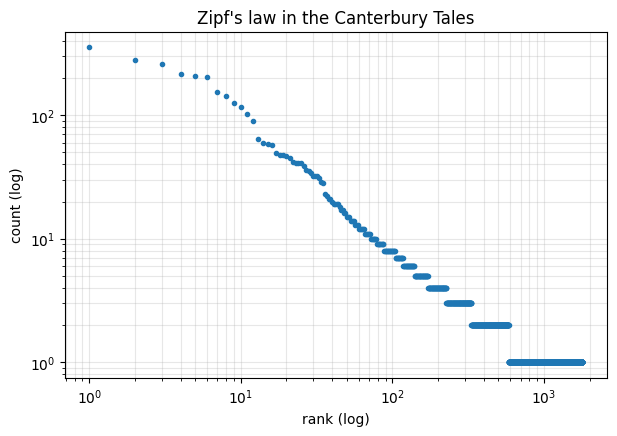

In [25]:
import urllib.request, numpy as np
import matplotlib.pyplot as plt
from collections import Counter

URL = ('https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/'
       'refs/heads/main/Workbook/Day%201%E2%80%94Traditional%20Philology/Canterbury%20Tales.txt')
full = urllib.request.urlopen(URL).read().decode('utf-8')
tokens = [w.lower().strip('.,;:!?()"\'') for w in full.split()]
tokens = [w for w in tokens if w]
freq = Counter(tokens)
print(f'{len(tokens):,} words, {len(freq):,} distinct.')

values = [n for _, n in freq.most_common()]
ranks = np.arange(1, len(values) + 1)
plt.figure(figsize=(7, 4.5))
plt.loglog(ranks, values, marker='.', linestyle='none')
plt.xlabel('rank (log)'); plt.ylabel('count (log)')
plt.title("Zipf's law in the Canterbury Tales"); plt.grid(True, which='both', alpha=0.3)
plt.show()

### A concordance

Pick any word and pull up every place it occurs, in context. This is a *concordance*, a tool philologists once spent years building by hand. Now it is instant.

In [26]:
STOP = set('the a an and or but of to in on at by for with as is was were be that this which who his '
           'her he she it they them him so then than do up out when their all from if no not there have '
           'has had would will shall may i you we us me my your our such some any every now yet also '
           'ye thou thee thy hath hir hem ne eke unto whan ther wel ful swich nas'.split())
keyword = next(w for w, _ in freq.most_common() if w not in STOP and len(w) > 3)

def kwic(word, width=4, limit=8):
    shown = 0
    for k, w in enumerate(tokens):
        if w == word:
            left  = ' '.join(tokens[max(0, k-width):k])
            right = ' '.join(tokens[k+1:k+1+width])
            print(f'{left:>34}  [ {word} ]  {right}')
            shown += 1
            if shown >= limit: break

print(f'Every occurrence of "{keyword}" in context:\n')
kwic(keyword)

Every occurrence of "well" in context:

           come into that hostelry  [ well ]  nine and twenty in
             stables were wide and  [ well ]  we weren eased at
                   no man farre as  [ well ]  in christendom as in
            picardie and borne him  [ well ]  as of so little
             sleeves long and wide  [ well ]  could he sit on
            coulde songes make and  [ well ]  indite joust and eke
                 and eke dance and  [ well ]  pourtray and write so
            he bare full thriftily  [ well ]  could he dress his


### The formulae fall out

Count runs of two and three words. The frequent ones are a text's set phrases. In the portraits of the pilgrims, the formula *he was a* opens one after another. You did not have to know it was there.

In [27]:
def ngrams(seq, n):
    return Counter(tuple(seq[i:i+n]) for i in range(len(seq)-n+1))

print('Most common trigrams:')
for gram, n in ngrams(tokens, 3).most_common(6):
    print(f'  {" ".join(gram):26} {n}')

content_bigrams = Counter((a, b) for a, b in zip(tokens, tokens[1:])
                          if a not in STOP and b not in STOP)
print('\nContent phrases (function words removed):')
for gram, n in content_bigrams.most_common(6):
    print(f'  {" ".join(gram):26} {n}')

Most common trigrams:
  he was a                   13
  well could he              11
  he had a                   7
  as is a                    6
  there was no               5
  there was a                5

Content phrases (function words removed):
  well could                 14
  full fair                  5
  full many                  5
  worthy man                 4
  full often                 3
  full well                  3


### One number for a whole text

*Shannon entropy* boils a text down to a single number: its average surprise per word, in bits. It is the backbone of compression and of every language model. Shuffle the words and the number does not move, which tells you exactly what this measure does and does not capture.

In [28]:
import math
def entropy(items):
    n = len(items)
    return -sum((c/n) * math.log2(c/n) for c in Counter(items).values())

import random
shuffled = tokens[:]; random.Random(0).shuffle(shuffled)
print('Word entropy:         ', round(entropy(tokens), 3), 'bits per word')
print('After shuffling words:', round(entropy(shuffled), 3), 'bits per word')
print('Same number. Word entropy says nothing about word order.')

Word entropy:          8.519 bits per word
After shuffling words: 8.519 bits per word
Same number. Word entropy says nothing about word order.


# Part 2 · Weighing the witnesses

We almost never have the original. The *Canterbury Tales* survive in about eighty handwritten copies, no two identical. The editor's job is to weigh the copies and decide what Chaucer wrote.

When two copies of a line disagree, the computer shows you exactly where. The rhyme with *londes* tells you Chaucer wrote *strondes*, even though it is not the majority reading.

In [29]:
import difflib
witness_1 = 'And palmeres for to seken straunge contrees'
witness_2 = 'And palmeres for to seken straunge strondes'
for d in difflib.ndiff(witness_1.split(), witness_2.split()):
    print(d)    # '-' only in copy 1, '+' only in copy 2, ' ' in both

  And
  palmeres
  for
  to
  seken
  straunge
- contrees
+ strondes


### Lining up four witnesses

Scale it up. Here is the first line of the *General Prologue* as four real scribes wrote it. Line them up word by word and the disagreements (mostly spelling) jump out. A computer does this across eighty manuscripts at once.

In [30]:
witnesses = {
 'Hengwrt':   'Whan that Aueryll wt his shoures soote',
 'Ellesmere': 'WHan that Aprill with hise shoures soote',
 'Harley':    'Whan that aprille with his schowres swoote',
 'Laud':      'WHan that Aprill wyth his schoures soote',
}
rows = {name: line.split() for name, line in witnesses.items()}
ncol = max(len(r) for r in rows.values())
print('   ' + '  '.join(f'{name:10}' for name in rows))
print('   ' + '  '.join('-'*10 for _ in rows))
for c in range(ncol):
    forms = [rows[name][c] if c < len(rows[name]) else '' for name in rows]
    mark = ' ' if len({f.lower() for f in forms}) == 1 else '*'   # * = scribes disagree
    print(f'{mark}  ' + '  '.join(f'{f:10}' for f in forms))

   Hengwrt     Ellesmere   Harley      Laud      
   ----------  ----------  ----------  ----------
   Whan        WHan        Whan        WHan      
   that        that        that        that      
*  Aueryll     Aprill      aprille     Aprill    
*  wt          with        with        wyth      
*  his         hise        his         his       
*  shoures     shoures     schowres    schoures  
*  soote       soote       swoote      soote     


# Part 3 · Script as data

From text to handwriting. A letter is not one shape. It is a range of shapes, because no two scribes draw it the same way. *Hieratic* is the cursive script of ancient Egypt. Here is one sign, *G17* (the owl, 𓅓), drawn many ways in a single Middle Egyptian text.

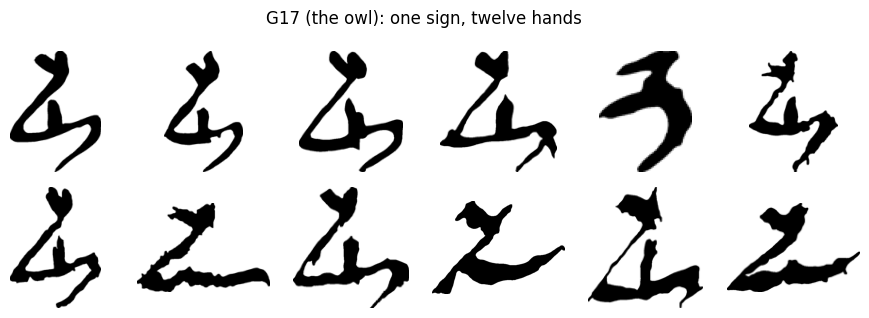

In [31]:
import io, csv, urllib.request
from PIL import Image
import matplotlib.pyplot as plt

ISUT = ('https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/'
        'refs/heads/main/Workbook/Day%207%E2%80%94Visualization/Isut/')

def g17_crops(folder, n=12):
    csv_url = ISUT + folder + '/overlay_output/all_colored_signs.csv'
    rows = [r for r in csv.DictReader(io.StringIO(
                urllib.request.urlopen(csv_url).read().decode('utf-8')))
            if r['unicode_key'] == 'U+13153'][:n]      # U+13153 = Gardiner G17, the owl
    owls = []
    for r in rows:
        rel = r['image_path'].replace('texts/', '', 1)
        im  = Image.open(io.BytesIO(urllib.request.urlopen(ISUT + rel).read())).convert('RGBA')
        owls.append(Image.alpha_composite(Image.new('RGBA', im.size, (255,255,255,255)), im))
    return owls

owls = g17_crops('Shipwrecked', 12)
fig, axes = plt.subplots(2, 6, figsize=(9, 3.2))
for ax, im in zip(axes.ravel(), owls):
    ax.imshow(im); ax.axis('off')
fig.suptitle('G17 (the owl): one sign, twelve hands')
plt.tight_layout(); plt.show()

### How a machine reads handwriting

This is the heart of *handwritten text recognition* (HTR), the technology that turns photographs of manuscripts into searchable text. The classic teaching example is handwritten digits. We load 70,000 of them, each a 28x28 grid of pixels.

In [32]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
y = y.astype(int)
rng = np.random.default_rng(0)
idx = rng.choice(len(X), 8000, replace=False)
X = X[idx] / 255.0
y = y[idx]
Xtr, Xte, ytr, yte = X[:6000], X[6000:], y[:6000], y[6000:]
print('Loaded', X.shape[0], 'digits.  Learning from', len(Xtr), ', testing on', len(Xte))

Loaded 8000 digits.  Learning from 6000 , testing on 2000


Every digit is 784 numbers, far too many to picture. Flatten them to a flat chart with PCA and the ten digits already pull apart into ten clouds, with no labels used to place them.

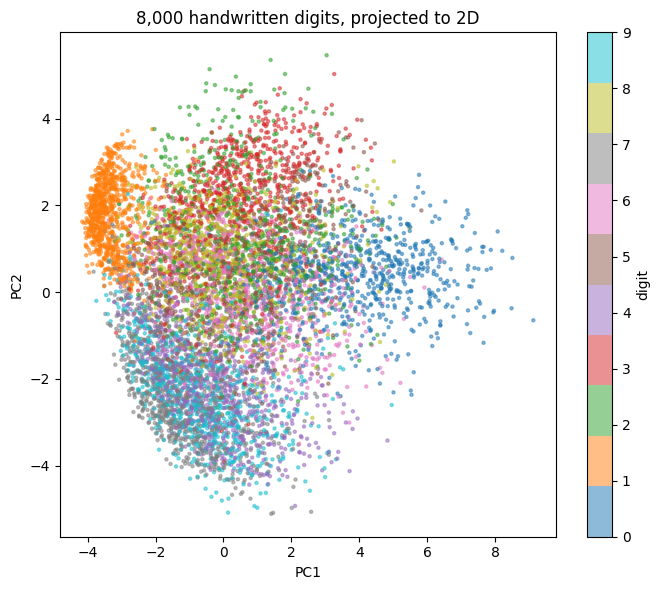

In [33]:
coords = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(7, 6))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=y, cmap='tab10', s=5, alpha=0.5)
plt.colorbar(sc, ticks=range(10), label='digit')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('8,000 handwritten digits, projected to 2D')
plt.tight_layout(); plt.show()

Now train a simple classifier on 6,000 examples and let it read 2,000 it has never seen.

In [34]:
pca50 = PCA(n_components=50).fit(Xtr)
knn = KNeighborsClassifier(n_neighbors=10).fit(pca50.transform(Xtr), ytr)
proba = knn.predict_proba(pca50.transform(Xte))
pred = proba.argmax(1)
confidence = proba.max(1)
print(f'It read {(pred == yte).sum()} of {len(yte)} correctly: {accuracy_score(yte, pred):.1%} accuracy.')

It read 1887 of 2000 correctly: 94.3% accuracy.


The interesting part is where it fails. These are the digits it was least sure about. Many are ones a person would also squint at. The same failure modes show up when machines read real scribal hands.

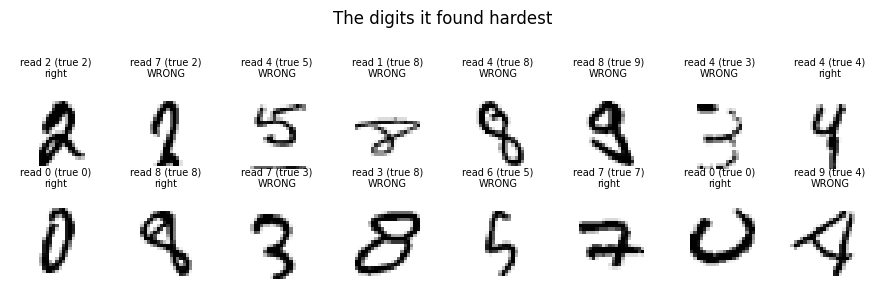

Most common confusion: a real 4 read as a 9 (11 times).


In [35]:
order = np.argsort(confidence)        # least confident first
fig, axes = plt.subplots(2, 8, figsize=(9, 2.8))
for ax, i in zip(axes.ravel(), order[:16]):
    ax.imshow(Xte[i].reshape(28, 28), cmap='gray_r')
    mark = 'right' if pred[i] == yte[i] else 'WRONG'
    ax.set_title(f'read {pred[i]} (true {yte[i]})\n{mark}', fontsize=7)
    ax.axis('off')
fig.suptitle('The digits it found hardest', y=1.04)
plt.tight_layout(); plt.show()

cm = confusion_matrix(yte, pred); off = cm.copy(); np.fill_diagonal(off, 0)
a, b = np.unravel_index(off.argmax(), off.shape)
print(f'Most common confusion: a real {a} read as a {b} ({off[a, b]} times).')

### From digits to scribes

The same move, now on the owls. Turn every drawing of *G17* from two Middle Egyptian texts into a row of numbers and project to two dimensions. The owls separate into distinct forms, and one form appears almost only in the *Shipwrecked Sailor*. This reproduces a published result. Fetching the images takes up to a minute.

fetching Peasant B1 ...
fetching Shipwrecked ...


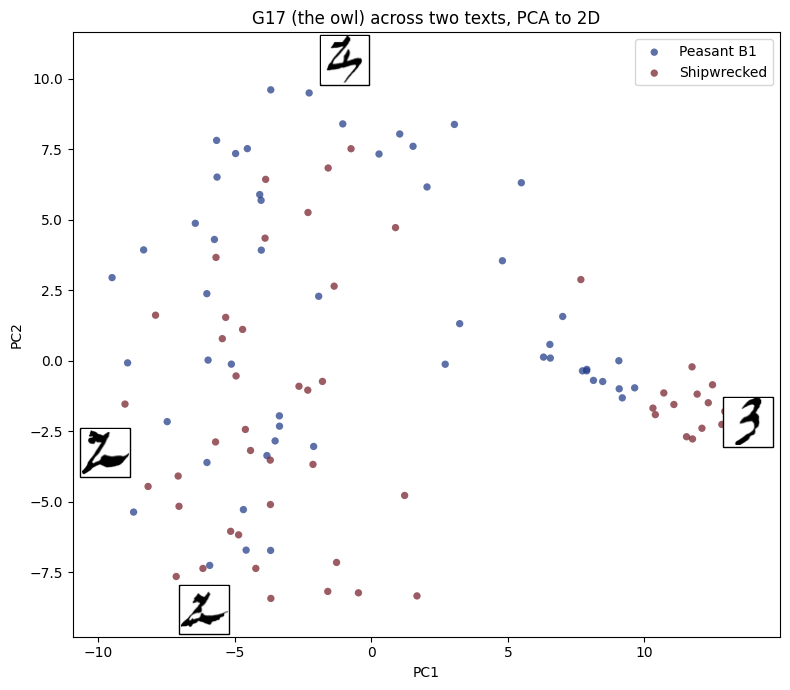

In [36]:
from sklearn.cluster import KMeans
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

FOLDER = {'Peasant B1': 'PeasantB1', 'Shipwrecked': 'Shipwrecked'}
CAP = 55     # a sample of each text keeps the live demo fast

def load_sign(folder, cap=CAP, size=48):
    rows = [r for r in csv.DictReader(io.StringIO(
                urllib.request.urlopen(ISUT + folder + '/overlay_output/all_colored_signs.csv').read().decode('utf-8')))
            if r['unicode_key'] == 'U+13153'][:cap]
    vecs, crops = [], []
    for r in rows:
        rel  = r['image_path'].replace('texts/', '', 1)
        im   = Image.open(io.BytesIO(urllib.request.urlopen(ISUT + rel).read())).convert('RGBA')
        gray = Image.alpha_composite(Image.new('RGBA', im.size, (255,255,255,255)), im).convert('L')
        w, h = gray.size; s = max(w, h)
        sq = Image.new('L', (s, s), 255); sq.paste(gray, ((s-w)//2, (s-h)//2))
        small = sq.resize((size, size))
        crops.append(small); vecs.append(255.0 - np.asarray(small, float))
    return np.array([v.ravel() for v in vecs]) / 255.0, crops

Xh, labels, crops = [], [], []
for name, folder in FOLDER.items():
    print('fetching', name, '...')
    V, C = load_sign(folder)
    Xh.append(V); crops += C; labels += [name] * len(V)
Xh = np.vstack(Xh); labels = np.array(labels)

Z = PCA(n_components=2).fit_transform(Xh - Xh.mean(0))
color = {'Shipwrecked': '#7a2630', 'Peasant B1': '#27408b'}
fig, ax = plt.subplots(figsize=(8, 7))
for name in FOLDER:
    m = labels == name
    ax.scatter(Z[m,0], Z[m,1], c=color[name], s=28, alpha=0.75, edgecolors='none', label=name)
for i in {Z[:,0].argmin(), Z[:,0].argmax(), Z[:,1].argmin(), Z[:,1].argmax()}:
    ax.add_artist(AnnotationBbox(OffsetImage(np.asarray(crops[i]), cmap='gray', zoom=0.7),
                                 (Z[i,0], Z[i,1]), frameon=True, pad=0.1))
ax.legend(); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('G17 (the owl) across two texts, PCA to 2D')
plt.tight_layout(); plt.show()

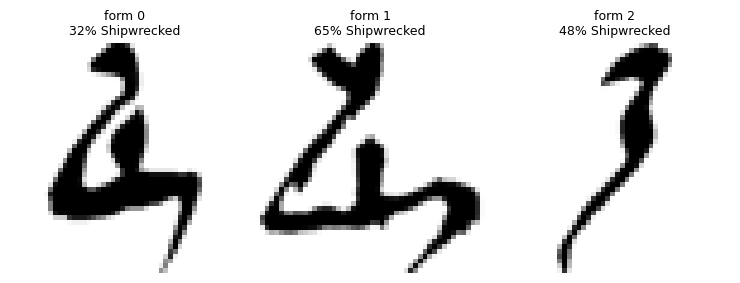

In [37]:
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Z)
fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.8))
for c in range(3):
    m = km.labels_ == c
    ship = int(((labels == 'Shipwrecked') & m).sum()); total = int(m.sum())
    medoid = np.where(m)[0][np.argmin(((Z[m] - Z[m].mean(0))**2).sum(1))]
    axes[c].imshow(crops[medoid], cmap='gray'); axes[c].axis('off')
    axes[c].set_title(f'form {c}\n{ship/total:.0%} Shipwrecked', fontsize=9)
plt.tight_layout(); plt.show()

# Part 4 · Even the sound

We have no recording of Chaucer, and none of Coptic either. So before measuring speech we cannot hear, we build speech ourselves. A vowel is a buzz from the vocal folds shaped by the resonances of the mouth. Give a plain buzz the right resonances, the *formants*, and it comes out as a vowel. Here is one built from scratch, from a handful of numbers. Run it and listen.

In [38]:
import numpy as np
from scipy.signal import lfilter
from IPython.display import Audio, display
fs = 16000   # sampling rate, Hz

def synth_vowel(formants, f0=120, dur=0.6, fs=fs):
    """A buzz at pitch f0, shaped by one resonator per formant (freq_Hz, bandwidth_Hz)."""
    n = int(dur * fs)
    source = np.zeros(n); source[::int(fs / f0)] = 1.0          # glottal pulses
    out = source.copy()
    for freq, bw in formants:
        r = np.exp(-np.pi * bw / fs); theta = 2 * np.pi * freq / fs
        out = lfilter([1 - r], [1, -2*r*np.cos(theta), r*r], out)
    return out / np.max(np.abs(out))

a = synth_vowel([(730, 70), (1090, 70), (2440, 90), (3500, 120), (4500, 150)])   # /a/ as in father
print('/a/ as in father:')
Audio(a, rate=fs)

/a/ as in father:


The five vowels are just five lists of numbers. Run this and listen to each. The only thing that changes from one to the next is those formant frequencies.

In [39]:
VOWELS = {
    'i (beet)':   [270, 2290, 3010, 3500, 4500],
    'e (bait)':   [530, 1840, 2480, 3500, 4500],
    'a (father)': [730, 1090, 2440, 3500, 4500],
    'o (bought)': [570,  840, 2410, 3500, 4500],
    'u (boot)':   [300,  870, 2240, 3500, 4500],
}
for name, F in VOWELS.items():
    print(name)
    display(Audio(synth_vowel([(f, 80) for f in F]), rate=fs))

i (beet)


e (bait)


a (father)


o (bought)


u (boot)


Now change a single number. Hold the first formant steady and raise the second, and the vowel slides from the back of the mouth to the front. One knob moves the whole front-to-back axis of speech. Listen from low to high.

In [40]:
F1 = 500
for f2 in [900, 1200, 1500, 1800, 2100, 2400]:      # back -> front
    print(f'F2 = {f2} Hz')
    display(Audio(synth_vowel([(F1, 80), (f2, 90), (2800, 120)]), rate=fs))

F2 = 900 Hz


F2 = 1200 Hz


F2 = 1500 Hz


F2 = 1800 Hz


F2 = 2100 Hz


F2 = 2400 Hz


Plot each vowel by its first two formants and you get the *vowel space*, a map of the mouth. F1 tracks how open the mouth is, F2 how far forward the tongue sits. Speech analysis starts here, with real recordings measured into this same chart.

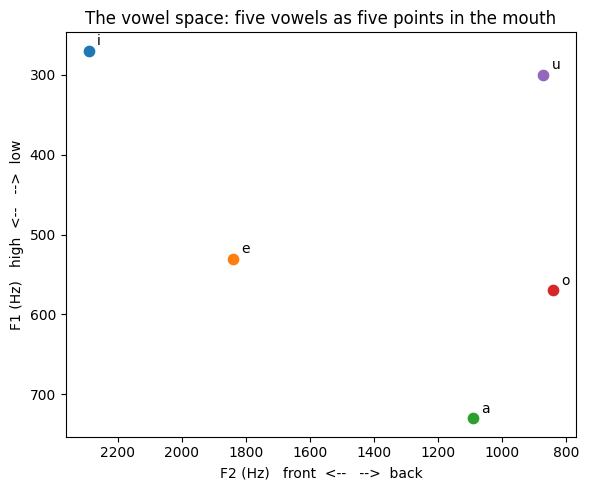

In [41]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 5))
for name, F in VOWELS.items():
    ax.scatter(F[1], F[0], s=55)
    ax.annotate(name.split()[0], (F[1], F[0]), xytext=(6, 4), textcoords='offset points')
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_xlabel('F2 (Hz)   front  <--   -->  back'); ax.set_ylabel('F1 (Hz)   high  <--   -->  low')
ax.set_title('The vowel space: five vowels as five points in the mouth')
plt.tight_layout(); plt.show()

And these vowels move. Over the centuries after Chaucer, the long vowels of English slid around this very space in a chain called the *Great Vowel Shift*. It is why some of his rhymes no longer rhyme. The arrows show the movement.

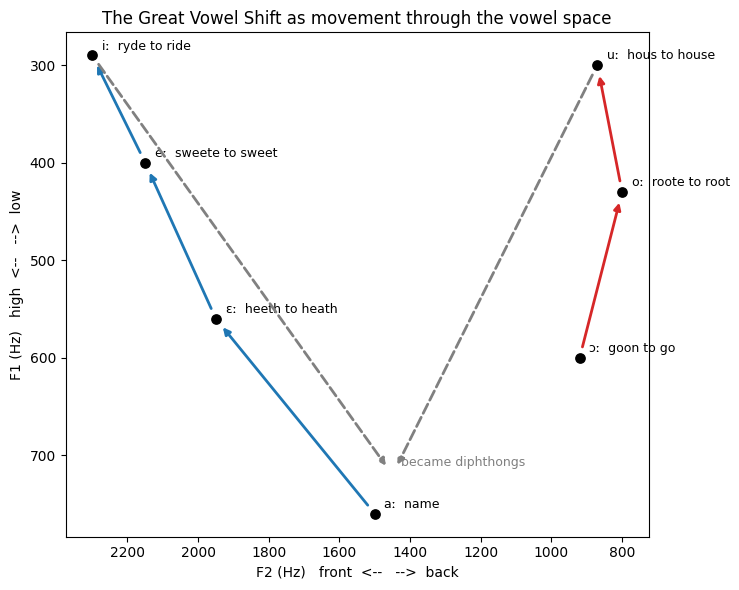

In [42]:
chain_front = ['aː', 'ɛː', 'eː', 'iː']
chain_back  = ['ɔː', 'oː', 'uː']
pos = {'iː':(2300,290),'eː':(2150,400),'ɛː':(1950,560),'aː':(1500,760),
       'uː':(870,300),'oː':(800,430),'ɔː':(920,600)}
word = {'iː':'ryde to ride','eː':'sweete to sweet','ɛː':'heeth to heath',
        'aː':'name','uː':'hous to house','oː':'roote to root','ɔː':'goon to go'}
fig, ax = plt.subplots(figsize=(7.5, 6))
for v, (f2, f1) in pos.items():
    ax.scatter(f2, f1, s=45, color='black', zorder=3)
    ax.annotate(f'{v}  {word[v]}', (f2, f1), xytext=(7, 4), textcoords='offset points', fontsize=9)
def chain(seq, color):
    for a, b in zip(seq, seq[1:]):
        ax.annotate('', xy=pos[b], xytext=pos[a],
                    arrowprops=dict(arrowstyle='-|>', color=color, lw=2, shrinkA=8, shrinkB=8))
chain(chain_front, 'C0'); chain(chain_back, 'C3')
for v in ['iː', 'uː']:
    ax.annotate('', xy=(1450, 720), xytext=pos[v],
                arrowprops=dict(arrowstyle='-|>', color='gray', lw=2, ls='--', shrinkA=8, shrinkB=8))
ax.annotate('became diphthongs', (1450, 720), xytext=(6, 6), textcoords='offset points',
            fontsize=9, color='gray')
ax.set_xlabel('F2 (Hz)   front  <--   -->  back'); ax.set_ylabel('F1 (Hz)   high  <--   -->  low')
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_title('The Great Vowel Shift as movement through the vowel space')
plt.tight_layout(); plt.show()

### The real payoff: a dead language's vowels

Those were built or living voices. Here is the result that is actually new. Egyptologists have argued for a century about how Coptic vowels sounded, and eta (ⲏ) alone has been placed all over the chart. Measure real recordings of the Coptic vowels and each letter lands at a definite point. Then build each vowel back from its measured formants and listen to a language no one has spoken in a thousand years.

In [43]:
# Measure real Coptic vowel recordings from the repo, place them, and hear them rebuilt.
try:
    import parselmouth
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'praat-parselmouth']); import parselmouth
import urllib.request, tempfile, os
from IPython.display import Audio, display

CB = ('https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/'
      'refs/heads/main/Workbook/Day%205%E2%80%94Sound%20as%20Data/coptic_audio/')
VOWELS = {'iota':('I','ⲓ'), 'eta':('H','ⲏ'), 'epsilon':('ε','ⲉ'), 'alpha':('λ','ⲁ'),
          'omicron':('O','ⲟ'), 'upsilon':('Y','ⲩ'), 'omega':('ω','ⲱ'), 'ou':('OY','ⲟⲩ')}

def measure(path, maxf=5500):
    snd = parselmouth.Sound(path)
    if snd.n_channels > 1: snd = snd.convert_to_mono()
    fm = snd.to_formant_burg(maximum_formant=maxf)
    d = snd.get_total_duration(); ts = np.linspace(0.3*d, 0.7*d, 15)
    return (np.nanmean([fm.get_value_at_time(1,t) for t in ts]),
            np.nanmean([fm.get_value_at_time(2,t) for t in ts]))

cent = {}
for v in VOWELS:
    pts = []
    for k in range(1, 6):
        try:
            raw = urllib.request.urlopen(CB + f'{v}_{k}.wav').read()
            with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tf:
                tf.write(raw); p = tf.name
            pts.append(measure(p)); os.remove(p)
        except Exception:
            pass
    if pts:
        cent[v] = np.mean(pts, 0)

if cent:
    fig, ax = plt.subplots(figsize=(6.8, 5.8))
    for v, (f1, f2) in cent.items():
        ax.scatter(f2, f1, s=90, color='C3')
        ax.annotate(VOWELS[v][0], (f2, f1), xytext=(7, 4), textcoords='offset points', fontsize=13)
    ax.invert_xaxis(); ax.invert_yaxis()
    ax.set_xlabel('F2 (Hz)   front  <--   -->  back'); ax.set_ylabel('F1 (Hz)   high  <--   -->  low')
    ax.set_title('The Coptic vowel space, measured from real recordings')
    plt.tight_layout(); plt.show()
    for v, (f1, f2) in cent.items():
        print(f'{VOWELS[v][1]} ({v}):  F1 = {f1:.0f} Hz,  F2 = {f2:.0f} Hz')
        display(Audio(synth_vowel([(f1,80),(f2,90),(2800,120),(3500,150),(4500,180)]), rate=fs))
else:
    print('Add the Coptic vowel clips under Day 5 / coptic_audio/ and push, to hear and plot them here.')

Add the Coptic vowel clips under Day 5 / coptic_audio/ and push, to hear and plot them here.


# That is the course

In ninety minutes you watched a text become countable, a hidden law appear, a concordance build itself, four scribes line up, a machine learn to read handwriting, an Egyptian sign sort itself into forms, and a dead language give up its vowels. The full two weeks goes slower and deeper, and you build and publish one small project of your own.

Papers can now carry interactive data too. Here is one of mine, a companion to a printed article: [Hieratic Sign Complexity over Time](https://writingthroughtime.github.io/hieratic-complexity-and-sign-names/).